# Stage2 Region Head Viewer

Stage2 `v1` のbbox交差断面について、4領域のEvidenceを個別に確認するnotebookです。

- 赤: Body
- 水色: Right foramen
- 緑: Left foramen
- オレンジ: Posterior
- 黄色枠: 元DICOMの骨折bboxをclassifier planeへ投影した位置
- bboxがあるclassifier planeだけを表示します。
- 1行が1断面、4列がBody / Right foramen / Left foramen / Posteriorです。
- 各パネルに領域scoreと、閾値による`DETECTED / not detected`を表示します。
- 色の濃さは各断面・各領域のsigmoid scoreを表します。

> `region score` は部位ラベルで教師あり学習した骨折確率ではなく、椎体ラベルから学習した弱教師Evidenceです。

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "train_models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

NOTEBOOK_DIR = PROJECT_ROOT / "train_models/stage2/notebook"
for path in (PROJECT_ROOT, NOTEBOOK_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"NOTEBOOK_DIR={NOTEBOOK_DIR}")

PROJECT_ROOT=/mnt/nfs1/home/yamamoto-hiroto/research/VAI
NOTEBOOK_DIR=/mnt/nfs1/home/yamamoto-hiroto/research/VAI/train_models/stage2/notebook


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from region_viz import (
    DEFAULT_OUTPUTS_DIR,
    build_oof_table,
    build_bbox_region_figure,
    get_bbox_overlays,
    infer_regions,
    load_model,
    load_sample_arrays,
    resolve_dataset_dir,
    select_samples,
)

plt.rcParams["figure.facecolor"] = "white"
pd.set_option("display.max_colwidth", 80)

## Parameters

In [3]:
FOLD = 0
CATEGORY = "TP"  # one of: TP, FN, FP, TN (region_pred_prob threshold=0.5)
N = 50
START_IDX = 0
GPU = 0

REGION_THRESHOLD = 0.5

OUTPUTS_DIR = DEFAULT_OUTPUTS_DIR
DATASET_DIR_OVERRIDE = None  # 例: Path("/data2/.../fracture_dataset")
SAVE_DPI = 140

## Load predictions and checkpoint

In [4]:
device = torch.device(f"cuda:{GPU}" if torch.cuda.is_available() else "cpu")
oof_table = build_oof_table(FOLD, OUTPUTS_DIR)
samples = select_samples(oof_table, CATEGORY, N, bbox_only=True)
model, config = load_model(FOLD, device, OUTPUTS_DIR)
dataset_dir = resolve_dataset_dir(config, DATASET_DIR_OVERRIDE)

print(f"device={device}")
print(f"checkpoint={OUTPUTS_DIR / f'fold{FOLD}' / 'best_model.pt'}")
print(f"dataset_dir={dataset_dir}")
print(f"{CATEGORY} samples with bbox in fold {FOLD}: {len(samples)}")

device=cuda:0
checkpoint=/mnt/nfs1/home/yamamoto-hiroto/research/VAI/train_models/stage2/outputs/baseline/v1/fold0/best_model.pt
dataset_dir=/mnt/nfs1/home/yamamoto-hiroto/research/VAI/data/rsna_data/fracture_dataset
TP samples in fold 0: 35 (bbox_only=True)


In [5]:
samples[[
    "study_uid",
    "vertebra",
    "label",
    "pred_prob",
    "region_pred_prob",
    "region_evidence_body",
    "region_evidence_right_foramen",
    "region_evidence_left_foramen",
    "region_evidence_posterior",
]].head(20)

,study_uid,vertebra,label,pred_prob,region_pred_prob,region_evidence_body,region_evidence_right_foramen,region_evidence_left_foramen,region_evidence_posterior
0,1.2.826.0.1.3680043.30549,C1,1,0.990183,0.999820,0.860635,0.728484,0.970558,0.845176
1,1.2.826.0.1.3680043.29805,C2,1,0.998388,0.999791,0.980489,0.828221,0.912141,0.722968
2,1.2.826.0.1.3680043.5671,C4,1,0.997626,0.998747,0.817255,0.913561,0.593765,0.776060
3,1.2.826.0.1.3680043.14267,C5,1,0.997859,0.998602,0.952778,0.590642,0.528400,0.928203
4,1.2.826.0.1.3680043.31077,C5,1,0.997955,0.997164,0.731634,0.815380,0.758505,0.838034
5,1.2.826.0.1.3680043.13444,C2,1,0.995569,0.996622,0.978209,0.926338,0.918399,0.700311
6,1.2.826.0.1.3680043.24477,C2,1,0.992000,0.996534,0.945942,0.978657,0.516487,0.745086
7,1.2.826.0.1.3680043.13203,C5,1,0.997547,0.995684,0.885186,0.430344,0.824388,0.828461
8,1.2.826.0.1.3680043.11401,C2,1,0.956652,0.994712,0.989628,0.339000,0.115129,0.272494
9,1.2.826.0.1.3680043.11103,C3,1,0.998011,0.987908,0.712841,0.493370,0.605353,0.845040


## Visualize one sample

`show_sample(index)`で表示し、`show_sample(index, save=True)`でPNGも保存します。

[1/35] 1.2.826.0.1.3680043.30549 / C1 GT=1 saved_primary=0.990 saved_region=1.000 current_primary=0.990 current_region=1.000


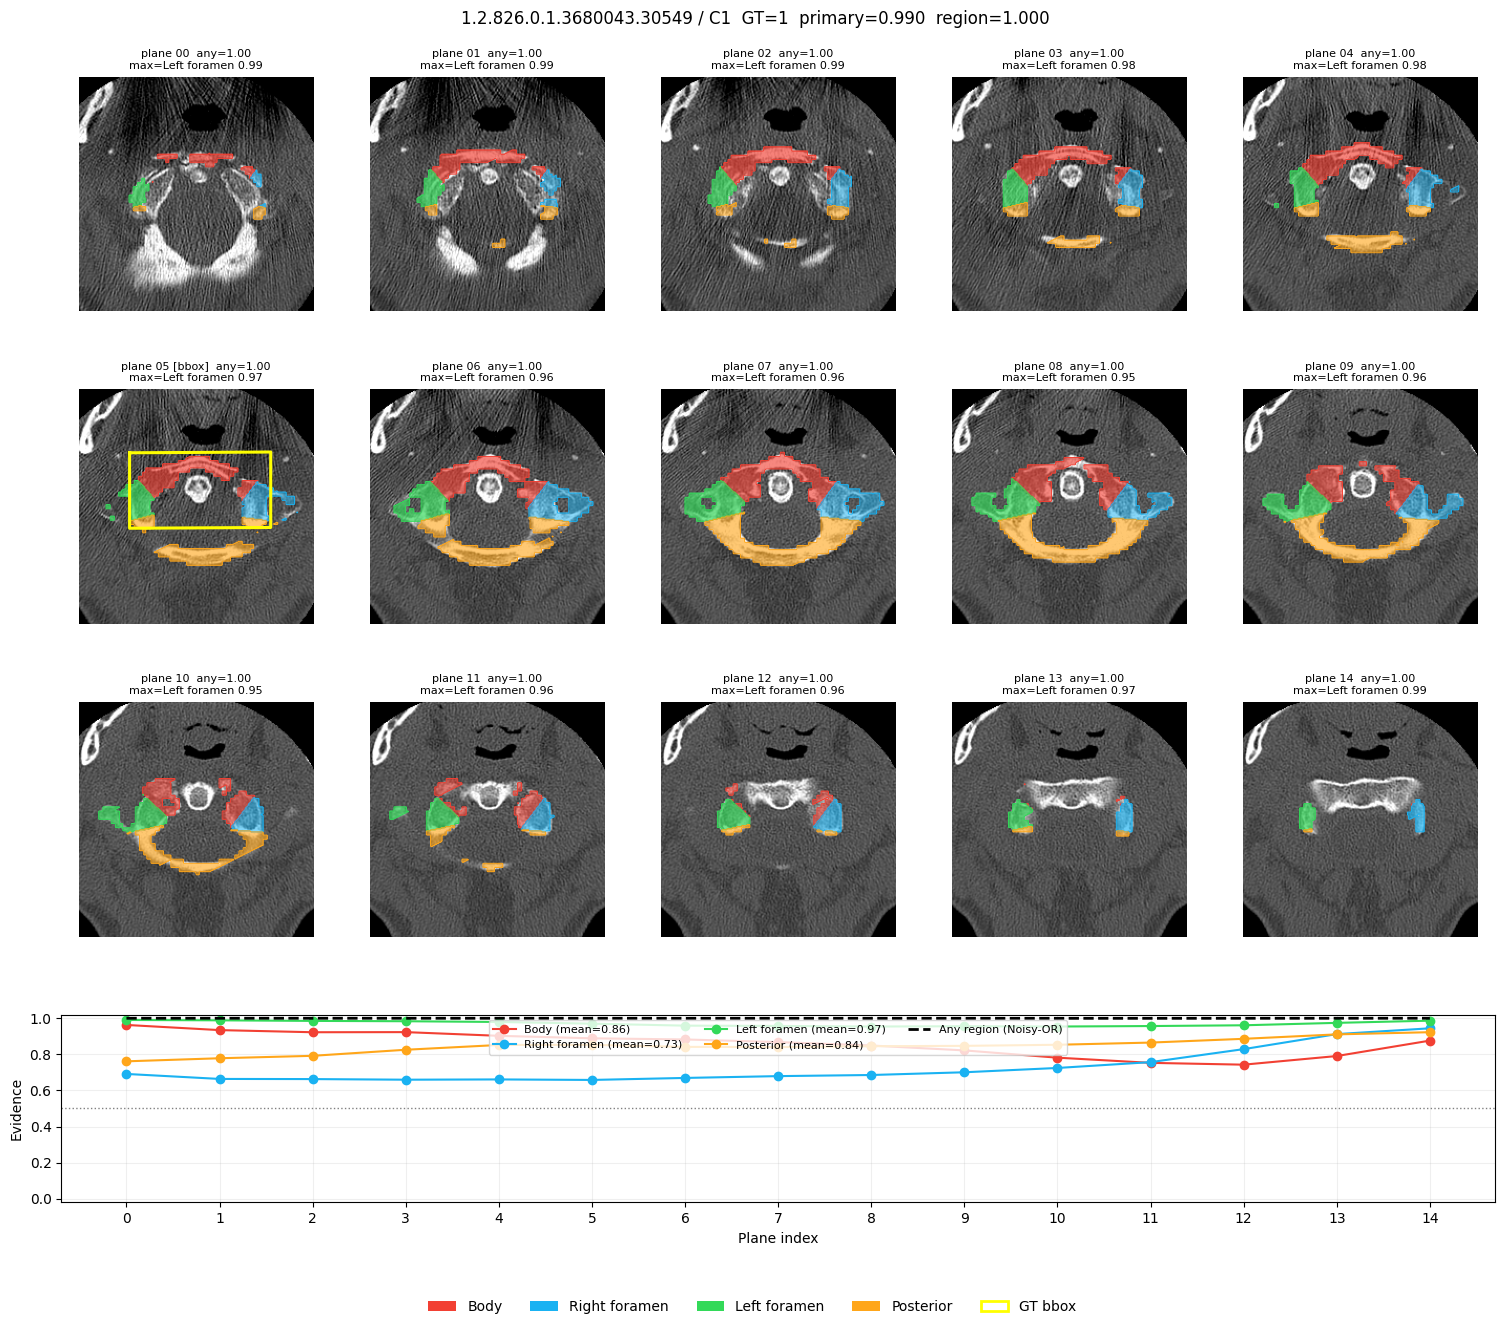

In [6]:
def show_sample(index: int, *, save: bool = False):
    if not 0 <= index < len(samples):
        raise IndexError(f"index must be in [0, {len(samples) - 1}]")

    row = samples.iloc[index]
    study_uid = str(row["study_uid"])
    vertebra = str(row["vertebra"])
    ct, vertebra_mask, region_mask = load_sample_arrays(
        study_uid,
        vertebra,
        dataset_dir,
    )
    inference = infer_regions(
        model,
        ct,
        vertebra_mask,
        region_mask,
        device,
    )
    bbox_overlays = get_bbox_overlays(study_uid, vertebra)
    if not bbox_overlays:
        raise ValueError(f"No projected bbox was found for {study_uid} / {vertebra}")
    figure = build_bbox_region_figure(
        study_uid,
        vertebra,
        int(row["label"]),
        ct,
        region_mask,
        inference,
        bbox_overlays,
        REGION_THRESHOLD,
    )

    print(
        f"[{index + 1}/{len(samples)}] {study_uid} / {vertebra} "
        f"GT={int(row['label'])} "
        f"saved_primary={float(row['pred_prob']):.3f} "
        f"saved_region={float(row['region_pred_prob']):.3f} "
        f"current_primary={inference.primary_probability:.3f} "
        f"current_region={inference.region_probability:.3f}"
    )
    if save:
        save_dir = OUTPUTS_DIR / "region_visualizations"
        save_dir.mkdir(parents=True, exist_ok=True)
        output_path = save_dir / f"fold{FOLD}_{study_uid}_{vertebra}.png"
        figure.savefig(output_path, dpi=SAVE_DPI, bbox_inches="tight")
        print(f"saved: {output_path}")

    display(figure)
    plt.close(figure)
    return inference


inference = show_sample(START_IDX)

## Optional widget

In [ ]:
try:
    import ipywidgets as widgets

    if len(samples) > 0:
        slider = widgets.IntSlider(
            value=min(START_IDX, len(samples) - 1),
            min=0,
            max=len(samples) - 1,
            step=1,
            description="sample",
            continuous_update=False,
        )
        widgets.interact(lambda index: show_sample(index), index=slider)
except ImportError:
    print("ipywidgets is not installed; call show_sample(index) directly.")

interactive(children=(IntSlider(value=0, continuous_update=False, description='sample', max=34), Output()), _d…